# Logistic Regression: Student Pass Prediction

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

### Load Dataset

In [2]:
df = pd.read_csv("student_pass.csv")
df.head()

,Student,Hours_Studied,Pass
0,1,6.39,1
1,2,0.25,0
2,3,2.23,1
3,4,6.77,1
4,5,8.92,1


### Visualize the Dataset

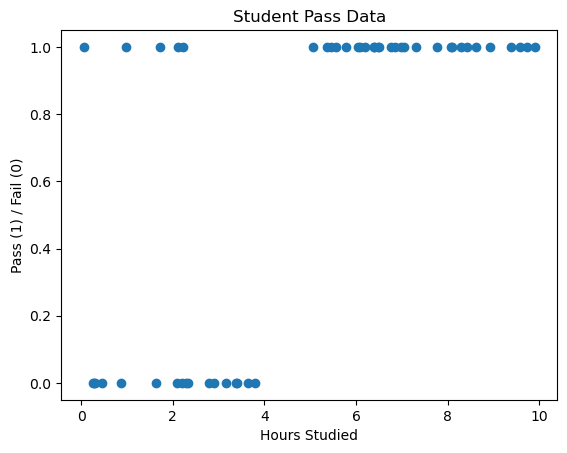

In [3]:
plt.scatter(df["Hours_Studied"], df["Pass"])
plt.xlabel("Hours Studied")
plt.ylabel("Pass (1) / Fail (0)")
plt.title("Student Pass Data")
plt.show()

### Prepare Data

In [4]:
X = df[["Hours_Studied"]]   # Feature must be 2D
y = df["Pass"]

### Train Logistic Regression Model

In [5]:
model = LogisticRegression()
model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Plot Logistic (Sigmoid) Curve

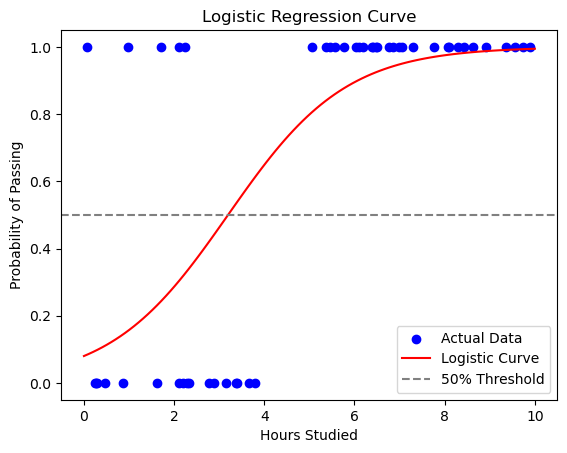

In [12]:
# Create smooth range of hours
hours_range = np.linspace(0, 10, 100).reshape(-1, 1)

# Convert to DataFrame with the correct feature name to remove the warning
X_range_df = pd.DataFrame(hours_range, columns=['Hours_Studied'])

# Predict probabilities
probabilities = model.predict_proba(X_range_df)[:, 1]

# Plot
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(hours_range, probabilities, color="red", label="Logistic Curve")

# Add threshold line (0.5 probability)
plt.axhline(0.5, color='gray', linestyle='--', label='50% Threshold')


plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression Curve")
plt.legend()
plt.show()

### Make Predictions

In [7]:
hours = pd.DataFrame([[5]], columns=["Hours_Studied"])

prediction = model.predict(hours)
probability = model.predict_proba(hours)

print("Prediction (0=Fail, 1=Pass):", prediction[0])
print("Probability of Passing:", probability[0][1])

Prediction (0=Fail, 1=Pass): 1
Probability of Passing: 0.7987711823590458


### Try Multiple Predictions

In [8]:
test_hours = pd.DataFrame([[2], [4], [6], [8]], columns=["Hours_Studied"])

probs = model.predict_proba(test_hours)[:, 1]

for i, h in enumerate(test_hours["Hours_Studied"]):
    print(f"Hours: {h} → Probability of Passing: {probs[i]:.2f}")

Hours: 2 → Probability of Passing: 0.29
Hours: 4 → Probability of Passing: 0.65
Hours: 6 → Probability of Passing: 0.89
Hours: 8 → Probability of Passing: 0.98
